Shape: (1001, 7)
   order_id customer_id sales_person  priority ship_mode       date  value_£
0      8999        C406        Kelly      High     Plane 2020-06-12  1553.44
1     47872        C100        Kelly  Critical     Plane 2020-06-12   315.40
2     29988        C006        Kelly      High     Lorry 2020-06-12  5075.89
3     37348        C492        Kelly      High     Plane 2020-06-13   520.67
4     28001        C231        Kelly  Critical     Plane 2020-06-14  8431.37
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1001 non-null   int64         
 1   customer_id   1001 non-null   object        
 2   sales_person  1001 non-null   object        
 3   priority      1001 non-null   object        
 4   ship_mode     1001 non-null   object        
 5   date          1001 non-null   datetime64[ns]
 6   value_£   

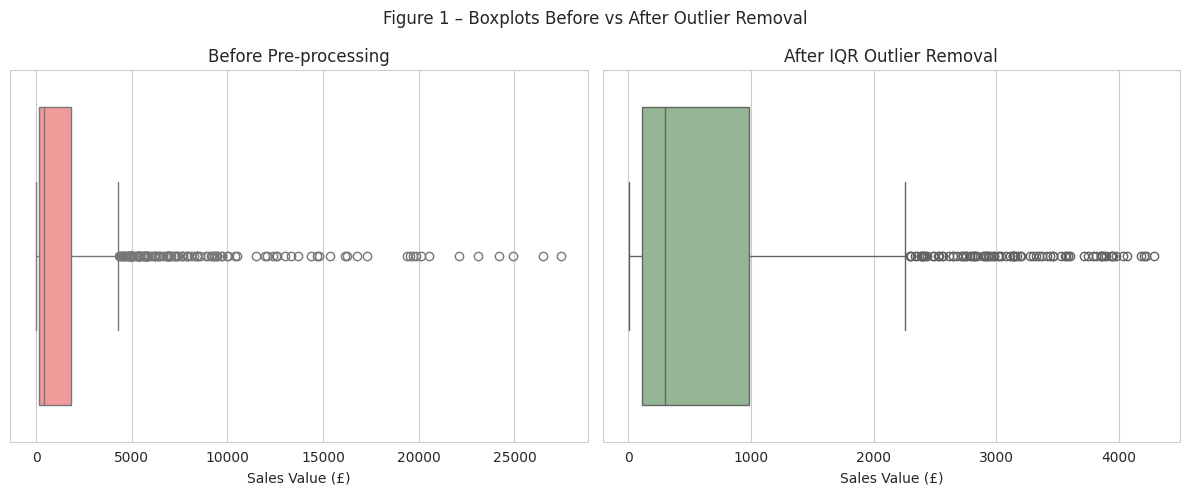

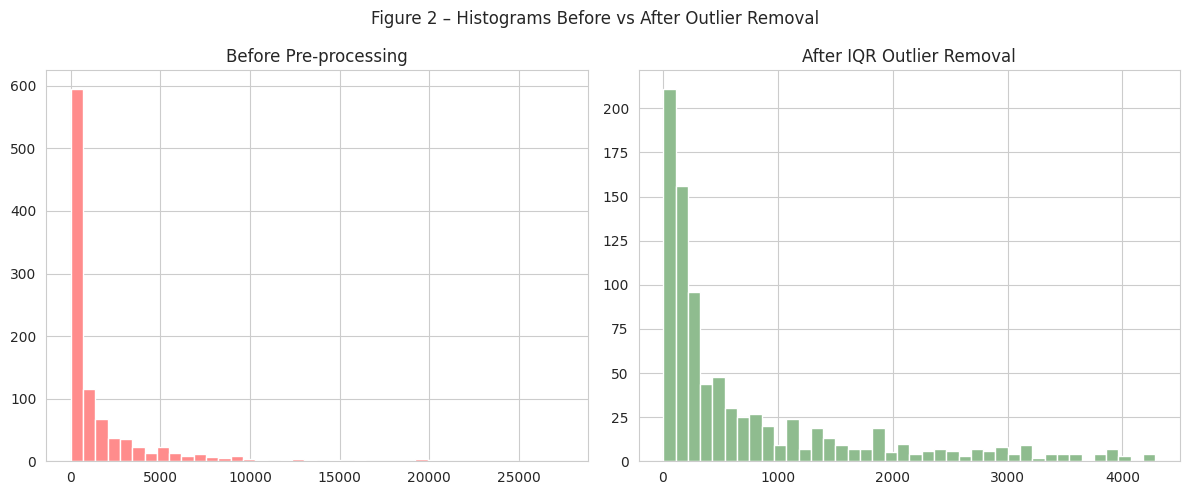


Sales person summary (cleaned):
                  Total     Avg  Count      Max
sales_person                                   
Pryia         229755.92  795.00    289  4227.02
Kelly         226801.95  804.26    282  4286.74
Peter         200322.99  650.40    308  4182.90


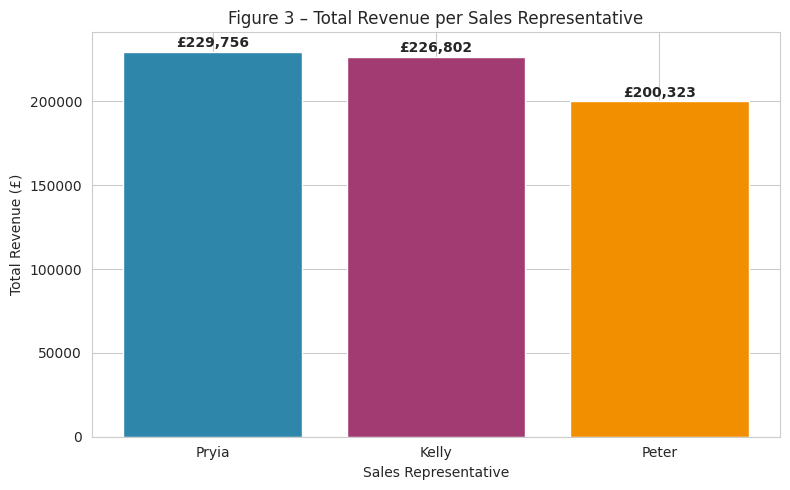

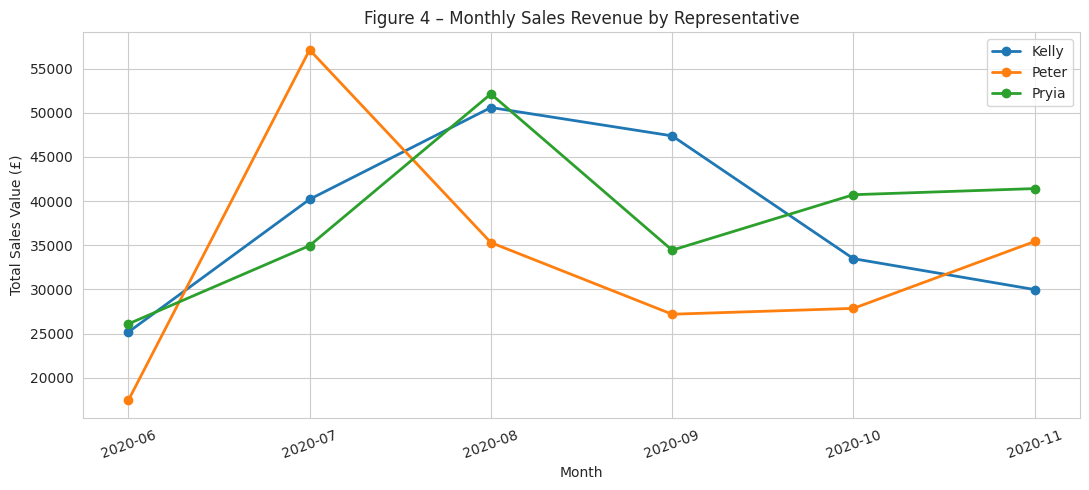


Correlation sample size: 691 rows
Spearman r=0.0461, p=0.2258
Pearson  r=0.0463, p=0.2242
Result: No significant correlation (p >= 0.05)


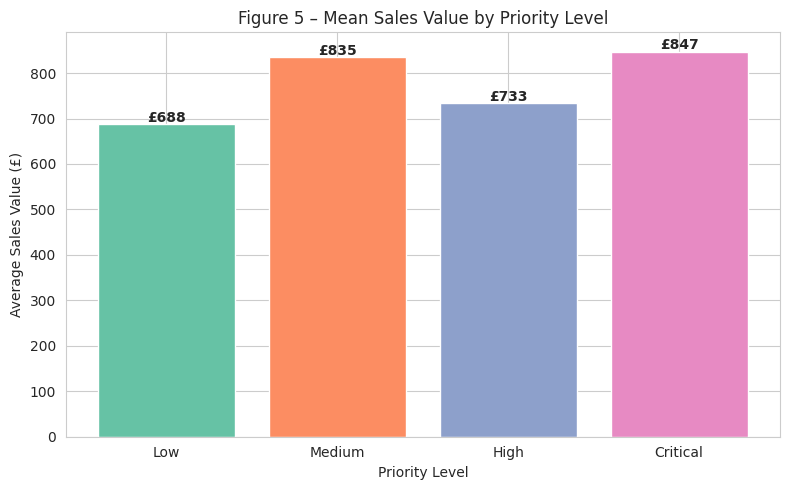

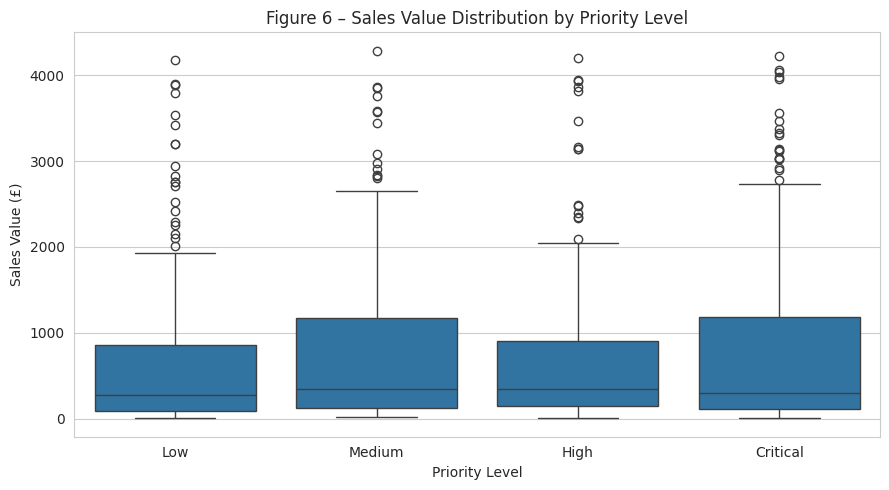


Revenue by shipping mode:
               Total  Count      Avg
ship_mode                           
Plane      435939.99    708   615.73
Lorry      137453.28     74  1857.48
Van         83487.59     97   860.70


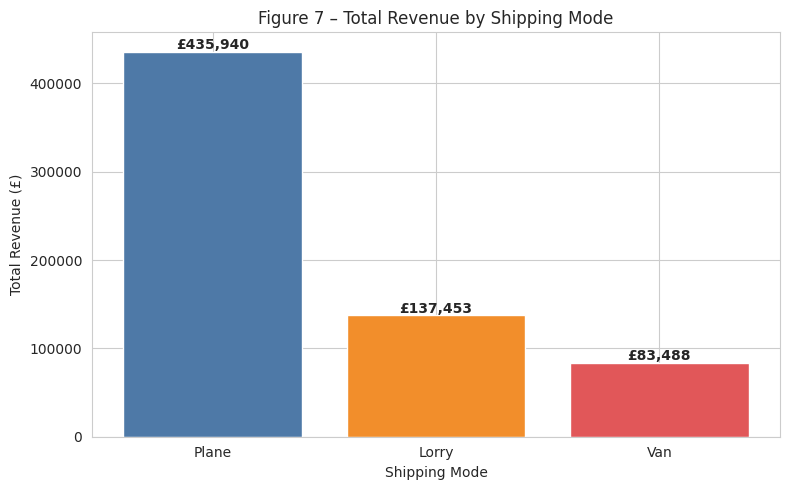


Cleaned dataset saved. Final shape: (879, 8)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

#1. ADDING DATASET
df = pd.read_excel('/Sales Data_PDA_4052.xlsx', skiprows=1)
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Shape:", df.shape)
print(df.head())
print(df.info())

#2. INITIAL QUALITY ASSESSMENT
print("\nDuplicated rows:", df.duplicated().sum())
print("\nNull counts:\n", df.isnull().sum())
print("\nPriority distribution:\n", df['priority'].value_counts())
print("\nShip mode distribution:\n", df['ship_mode'].value_counts())
print("\nSales person distribution:\n", df['sales_person'].value_counts())
print("\nvalue_£ statistics (raw):")
print(df['value_£'].describe())
print("Skewness:", round(df['value_£'].skew(), 2))

#3. HANDLe MISSING VALUES
df['priority'] = df['priority'].replace('Not Specified', np.nan)
print("\nNull counts after priority fix:\n", df.isnull().sum())

#4. OUTLIER DETECTION AND REMOVAL
Q1 = df['value_£'].quantile(0.25)
Q3 = df['value_£'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"\nQ1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Lower fence={lower:.2f}, Upper fence={upper:.2f}")

df_clean = df[(df['value_£'] >= lower) & (df['value_£'] <= upper)].copy()
print(f"Removed: {len(df) - len(df_clean)} rows | Retained: {len(df_clean)} rows")
print("Skewness after cleaning:", round(df_clean['value_£'].skew(), 2))

# Figure 1 – Boxplots before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df['value_£'], ax=axes[0], color='#FF8C8C')
axes[0].set_title('Before Pre-processing')
axes[0].set_xlabel('Sales Value (£)')
sns.boxplot(x=df_clean['value_£'], ax=axes[1], color='#8FBC8F')
axes[1].set_title('After IQR Outlier Removal')
axes[1].set_xlabel('Sales Value (£)')
plt.suptitle('Figure 1 – Boxplots Before vs After Outlier Removal')
plt.tight_layout()
plt.show()

# Figure 2 – Histograms before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['value_£'], bins=40, color='#FF8C8C', edgecolor='white')
axes[0].set_title('Before Pre-processing')
axes[1].hist(df_clean['value_£'], bins=40, color='#8FBC8F', edgecolor='white')
axes[1].set_title('After IQR Outlier Removal')
plt.suptitle('Figure 2 – Histograms Before vs After Outlier Removal')
plt.tight_layout()
plt.show()

#5. SALES REPRESENTATIVE ANALYSIS
df_clean['Month'] = df_clean['date'].dt.to_period('M')

summary = df_clean.groupby('sales_person')['value_£'].agg(
    Total='sum', Avg='mean', Count='count', Max='max'
).round(2).sort_values('Total', ascending=False)
print("\nSales person summary (cleaned):")
print(summary)

# Figure 3 – Total sales bar chart
totals = df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
bars = plt.bar(totals.index, totals.values, color=['#2E86AB','#A23B72','#F18F01'])
for bar, v in zip(bars, totals.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2500,
             f'£{v:,.0f}', ha='center', fontweight='bold')
plt.title('Figure 3 – Total Revenue per Sales Representative')
plt.xlabel('Sales Representative')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

# Figure 4 – Monthly line chart
monthly = df_clean.groupby(['Month','sales_person'])['value_£'].sum().unstack(fill_value=0)
plt.figure(figsize=(11, 5))
for person in monthly.columns:
    plt.plot(monthly.index.astype(str), monthly[person], marker='o', linewidth=2, label=person)
plt.title('Figure 4 – Monthly Sales Revenue by Representative')
plt.xlabel('Month')
plt.ylabel('Total Sales Value (£)')
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#6. PRIORITY VS VALUE CORRELATION
df_corr = df_clean.dropna(subset=['priority']).copy()
pmap = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_corr['priority_num'] = df_corr['priority'].map(pmap)
print(f"\nCorrelation sample size: {len(df_corr)} rows")

sp_r, sp_p = stats.spearmanr(df_corr['priority_num'], df_corr['value_£'])
pe_r, pe_p = stats.pearsonr(df_corr['priority_num'], df_corr['value_£'])
print(f"Spearman r={sp_r:.4f}, p={sp_p:.4f}")
print(f"Pearson  r={pe_r:.4f}, p={pe_p:.4f}")
if sp_p < 0.05:
    print("Result: Significant correlation (p < 0.05)")
else:
    print("Result: No significant correlation (p >= 0.05)")

order = ['Low', 'Medium', 'High', 'Critical']

#Figure 5 – Mean value by priority
by_priority = df_corr.groupby('priority')['value_£'].mean().reindex(order)
plt.figure(figsize=(8, 5))
bars = plt.bar(by_priority.index, by_priority.values,
               color=['#66C2A5','#FC8D62','#8DA0CB','#E78AC3'])
for bar, v in zip(bars, by_priority.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'£{v:,.0f}', ha='center', fontweight='bold')
plt.title('Figure 5 – Mean Sales Value by Priority Level')
plt.xlabel('Priority Level')
plt.ylabel('Average Sales Value (£)')
plt.tight_layout()
plt.show()

#Figure 6 – Distribution by priority (boxplot)
plt.figure(figsize=(9, 5))
sns.boxplot(x='priority', y='value_£', data=df_corr, order=order)
plt.title('Figure 6 – Sales Value Distribution by Priority Level')
plt.xlabel('Priority Level')
plt.ylabel('Sales Value (£)')
plt.tight_layout()
plt.show()

#7. REVENUE BY SHIPPING MODE
ship = df_clean.groupby('ship_mode')['value_£'].agg(
    Total='sum', Count='count', Avg='mean'
).round(2).sort_values('Total', ascending=False)
print("\nRevenue by shipping mode:")
print(ship)

#Figure 7 – Total revenue by shipping mode
plt.figure(figsize=(8, 5))
bars = plt.bar(ship.index, ship['Total'], color=['#4E79A7','#F28E2B','#E15759'])
for bar, v in zip(bars, ship['Total']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'£{v:,.0f}', ha='center', fontweight='bold')
plt.title('Figure 7 – Total Revenue by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

#8. SAVE CLEANED DATASET
df_clean.to_csv('sales_data_cleaned.csv', index=False)
print("\nCleaned dataset saved. Final shape:", df_clean.shape)
